In [7]:
import datasets_orig
import unet_orig
from SplitNet_orig import SplitNet
from training_orig import darcy_loss

import torch
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import Adam
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

torch.random.manual_seed(42)
np.random.seed(42)

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
def just_darcy(out) -> torch.Tensor:

    # If we assume the output is in order k,pres,phi
    # pres_grad is the gradient of the pressure along the y and x directions as a tuple
    pres_grad = torch.gradient(out[:, 1:2], dim=(-2,-1))

    # get velocity by multiplying the gradient by the conductivity
    y_grad = pres_grad[0] * out[:, 0:1]
    x_grad = pres_grad[1] * out[:, 0:1]

    # compute the divergence by the second derivative of the gradients and adding them together
    yy_grad = torch.gradient(y_grad, spacing=(1,),dim=(-2,))[0]
    xx_grad = torch.gradient(x_grad, spacing=(1,),dim=(-1,))[0]
    final = yy_grad + xx_grad

    # total divergence should be 0
    loss = (final**2)

    return loss

def make_model(model_type="splitnet_attn"):
    model_type = model_type.lower()

    if model_type == "splitnet_attn":
        return SplitNet(attn=True).to(device)
    elif model_type == "splitnet":
        return SplitNet(attn=False).to(device)
    elif model_type == "unet":
        return unet_orig.SmallUnet(channels=2).to(device)
    elif model_type == "attn_unet":
        return unet_orig.AttnUnet(channels=2).to(device)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")


def build_border_observed_mask(H=200, W=200):
    """
    Observed mask for BorderDenseDatasetFull:
    top 5 rows + bottom 5 rows
    """
    mask = torch.zeros((H, W), dtype=torch.bool)
    mask[0:5, :] = 1
    mask[-5:, :] = 1
    return mask


def mse_on_region(pred, target, region_mask):
    """
    pred, target: [B,C,H,W]
    region_mask: [B,1,H,W] or [B,C,H,W] boolean/numeric mask
    """
    region_mask = region_mask.float()
    diff2 = (pred - target) ** 2 * region_mask
    denom = region_mask.sum()
    if denom.item() == 0:
        return torch.tensor(0.0, device=pred.device)
    return diff2.sum() / denom


def expand_mask_for_channels(mask, pred):
    """
    mask expected shape [B,1,H,W]
    expand to [B,C,H,W]
    """
    return mask.expand(-1, pred.shape[1], -1, -1)

In [9]:
def make_loaders(train_sims, val_sims, test_sims, dataset_mode="border", batch_size=8):
    """
    dataset_mode options:
      - "border"
      - "fixed"
      - "random"

    Returns:
      train_loader, val_loader, test_loader
    """

    if dataset_mode == "border":
        train_data = datasets_orig.BorderThinDatasetLimited(train_sims, channels="KP")
        val_data   = datasets_orig.BorderThinDatasetLimited(val_sims, channels="KP")
        test_data  = datasets_orig.BorderDenseDatasetFull(test_sims, channels="KP")

    elif dataset_mode == "fixed":
        train_data = datasets_orig.FixedThinDatasetLimited(train_sims, channels="KP")
        val_data   = datasets_orig.FixedThinDatasetLimited(val_sims, channels="KP")
        test_data  = datasets_orig.FixedDenseDatasetFull(test_sims, channels="KP")

    elif dataset_mode == "random":
        train_data = datasets_orig.RandomDenseDatasetLimited(train_sims, channels="KP")
        val_data   = datasets_orig.RandomDenseDatasetLimited(val_sims, channels="KP")
        test_data  = datasets_orig.FixedDenseDatasetFull(test_sims, channels="KP")

    else:
        raise ValueError("dataset_mode must be 'border', 'fixed', or 'random'")

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [10]:
def evaluate_loader(model, loader, crit, dataset_kind="limited", observed_mask_full=None):
    """
    dataset_kind:
      - "limited" : loader returns feat, label, mask
      - "full"    : loader returns feat, label

    observed_mask_full:
      required for full datasets if you want observed/non-observed split
      shape [H,W]
    """
    model.eval()

    total_mse = 0.0
    total_mask_mse = 0.0
    total_nonmask_mse = 0.0
    total_darcy = 0.0
    n_batches = 0


    with torch.no_grad():
        for batch in loader:
            if dataset_kind == "limited":
                feat, label, mask = batch
                feat = feat.to(device)
                label = label.to(device)

                if mask.dim() == 3:
                    mask = mask.unsqueeze(1)
                mask = mask.to(device).bool()

                _, out = darcy_loss(model, feat)
                dmap = just_darcy(out)
                p_loss = dmap.mean()

                total_mse_batch = crit(out, label)

                mask_c = expand_mask_for_channels(mask, out)
                nonmask_c = ~mask_c

                mask_mse_batch = mse_on_region(out, label, mask_c)
                nonmask_mse_batch = mse_on_region(out, label, nonmask_c)

            elif dataset_kind == "full":
                feat, label = batch
                feat = feat.to(device)
                label = label.to(device)

                _, out = darcy_loss(model, feat)
                dmap = just_darcy(out)
                p_loss = dmap.mean()

                # Full datasets may still return 3-channel labels even when channels="KP"
                if label.shape[1] != out.shape[1]:
                    label = label[:, :out.shape[1]]

                total_mse_batch = crit(out, label)

                if observed_mask_full is None:
                    raise ValueError("observed_mask_full is required for full dataset evaluation")

                obs = observed_mask_full.to(device).unsqueeze(0).unsqueeze(0)
                obs = obs.expand(out.shape[0], 1, out.shape[2], out.shape[3])

                obs_c = expand_mask_for_channels(obs, out)
                nonobs_c = ~obs_c

                mask_mse_batch = mse_on_region(out, label, obs_c)
                nonmask_mse_batch = mse_on_region(out, label, nonobs_c)

            else:
                raise ValueError("dataset_kind must be 'limited' or 'full'")

            total_mse += total_mse_batch.item()
            total_mask_mse += mask_mse_batch.item()
            total_nonmask_mse += nonmask_mse_batch.item()
            total_darcy += p_loss.item()
            n_batches += 1

    return {
        "total_mse": total_mse / n_batches,
        "mask_mse": total_mask_mse / n_batches,
        "nonmask_mse": total_nonmask_mse / n_batches,
        "darcy": total_darcy / n_batches,
    }

In [ ]:
def run_experiment(
    model_type="splitnet_attn",
    dataset_mode="border",
    loss_weights=(1, 1),
    epochs=250,
    batch_size=8,
    lr=1e-3,
    save_prefix=None
):
    train_sims = np.load("../train_sims.npy")
    train_sims = train_sims[train_sims < 500]

    val_sims = np.load("../val_sims.npy")
    val_sims = val_sims[val_sims < 500]
    

    test_sims = np.load("../test_sims.npy")
    test_sims = test_sims[test_sims < 500]

    model = make_model(model_type)
    optim = Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()

    train_loader, val_loader, test_loader = make_loaders(
        train_sims, val_sims, test_sims,
        dataset_mode=dataset_mode,
        batch_size=batch_size
    )

    history = {
        "train_total": [],
        "train_mask": [],
        "train_nonmask": [],
        "train_darcy": [],
        "train_loss_used": [],
        "val_total": [],
        "val_mask": [],
        "val_nonmask": [],
        "val_darcy": [],
        "test_total": [],
        "test_mask": [],
        "test_nonmask": [],
        "test_darcy": [],
    }

    full_obs_mask = build_border_observed_mask()

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_path = None

    if save_prefix is not None:
        best_model_path = f"{save_prefix}_best_state.pt"

    for epoch in tqdm(range(1, epochs + 1)):
        model.train()

        epoch_loss_used = 0.0
        n_batches = 0

        for feat, label, mask in train_loader:
            optim.zero_grad()

            feat = feat.to(device)
            label = label.to(device)

            if label.shape[1] != feat.shape[1]:
                label = label[:, :feat.shape[1]]

            if mask.dim() == 3:
                mask = mask.unsqueeze(1)
            mask = mask.to(device).bool()

            p_loss, out = darcy_loss(model, feat)

            if label.shape[1] != out.shape[1]:
                label = label[:, :out.shape[1]]

            mask_c = expand_mask_for_channels(mask, out)

            loss = crit(out * mask_c.float(), label * mask_c.float()) * loss_weights[0] + p_loss * loss_weights[1]

            loss.backward()
            optim.step()

            epoch_loss_used += loss.item()
            n_batches += 1

        history["train_loss_used"].append(epoch_loss_used / n_batches)

        train_metrics = evaluate_loader(model, train_loader, crit, dataset_kind="limited")
        val_metrics = evaluate_loader(model, val_loader, crit, dataset_kind="limited")
        test_metrics = evaluate_loader(model, test_loader, crit, dataset_kind="full", observed_mask_full=full_obs_mask)

        history["train_total"].append(train_metrics["total_mse"])
        history["train_mask"].append(train_metrics["mask_mse"])
        history["train_nonmask"].append(train_metrics["nonmask_mse"])
        history["train_darcy"].append(train_metrics["darcy"])

        history["val_total"].append(val_metrics["total_mse"])
        history["val_mask"].append(val_metrics["mask_mse"])
        history["val_nonmask"].append(val_metrics["nonmask_mse"])
        history["val_darcy"].append(val_metrics["darcy"])

        history["test_total"].append(test_metrics["total_mse"])
        history["test_mask"].append(test_metrics["mask_mse"])
        history["test_nonmask"].append(test_metrics["nonmask_mse"])
        history["test_darcy"].append(test_metrics["darcy"])

        val_loss = val_metrics["total_mse"]

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            if best_model_path is not None:
                torch.save(model.state_dict(), best_model_path)

    print(f"Best epoch: {best_epoch}, best val loss: {best_val_loss:.6f}")

    if save_prefix is not None:
        torch.save(model, f"{save_prefix}_final_model.pt")

    return model, history

In [ ]:
# model_border_darcy, hist_border_darcy = run_experiment(
#     model_type="splitnet_attn",
#     dataset_mode="border",
#     loss_weights=(1, 1),
#     epochs=250,
#     save_prefix="minimum_info/border_splitattn_darcy.pt"
# )

# model_border_nodarcy, hist_border_nodarcy = run_experiment(
#     model_type="splitnet_attn",
#     dataset_mode="border",
#     loss_weights=(1, 0),
#     epochs=250,
#     save_prefix="minimum_info/border_splitattn_nodarcy.pt"
# )

model_fixed_darcy, hist_fixed_darcy = run_experiment(
    model_type="splitnet_attn",
    dataset_mode="fixed",
    loss_weights=(1, 1),
    epochs=250,
    save_prefix="minimum_info/fixed_splitattn_darcy.pt"
)

model_fixed_nodarcy, hist_fixed_nodarcy = run_experiment(
    model_type="splitnet_attn",
    dataset_mode="fixed",
    loss_weights=(1, 0),
    epochs=250,
    save_prefix="minimum_info/fixed_splitattn_nodarcy.pt"
)

model_random_darcy, hist_random_darcy = run_experiment(
    model_type="splitnet_attn",
    dataset_mode="random",
    loss_weights=(1, 1),
    epochs=250,
    save_prefix="minimum_info/random_splitattn_darcy.pt"
)

model_random_nodarcy, hist_random_nodarcy = run_experiment(
    model_type="splitnet_attn",
    dataset_mode="random",
    loss_weights=(1, 0),
    epochs=250,
    save_prefix="minimum_info/random_splitattn_nodarcy.pt"
)

  0%|          | 0/250 [00:00<?, ?it/s]

In [ ]:
model_border_nodarcy, hist_border_nodarcy = run_experiment(
    model_type="splitnet_attn",
    dataset_mode="border",
    loss_weights=(1, 0),
    epochs=250,
    save_path="minimum_info/border_splitattn_nodarcy.pt"
)

In [ ]:
model_fixed_darcy, hist_fixed_darcy = run_experiment(
    model_type="splitnet_attn",
    dataset_mode="fixed",
    loss_weights=(1, 1),
    epochs=250,
    save_path="minimum_info/fixed_splitattn_darcy.pt"
)

In [ ]:
model_fixed_nodarcy, hist_fixed_nodarcy = run_experiment(
    model_type="splitnet_attn",
    dataset_mode="fixed",
    loss_weights=(1, 0),
    epochs=250,
    save_path="minimum_info/fixed_splitattn_nodarcy.pt"
)

In [ ]:
model_random_darcy, hist_random_darcy = run_experiment(
    model_type="splitnet_attn",
    dataset_mode="random",
    loss_weights=(1, 1),
    epochs=250,
    save_path="minimum_info/random_splitattn_darcy.pt"
)

In [ ]:
model_random_nodarcy, hist_random_nodarcy = run_experiment(
    model_type="splitnet_attn",
    dataset_mode="random",
    loss_weights=(1, 0),
    epochs=250,
    save_path="minimum_info/random_splitattn_nodarcy.pt"
)

In [ ]:
def plot_history(hist, title="experiment"):
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.plot(hist["train_loss_used"], label="train loss used")
    plt.title(f"{title} - train objective")
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(hist["train_total"], label="train total mse")
    plt.plot(hist["val_total"], label="val total mse")
    plt.plot(hist["test_total"], label="test total mse")
    plt.title(f"{title} - total mse")
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(hist["train_mask"], label="train mask mse")
    plt.plot(hist["val_mask"], label="val mask mse")
    plt.plot(hist["test_mask"], label="test observed mse")
    plt.title(f"{title} - mask/observed mse")
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(hist["train_nonmask"], label="train nonmask mse")
    plt.plot(hist["val_nonmask"], label="val nonmask mse")
    plt.plot(hist["test_nonmask"], label="test unobserved mse")
    plt.plot(hist["train_darcy"], label="train darcy")
    plt.plot(hist["val_darcy"], label="val darcy")
    plt.plot(hist["test_darcy"], label="test darcy")
    plt.title(f"{title} - nonmask + darcy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
plot_history(hist_border_darcy, "Border + Darcy")
plot_history(hist_border_nodarcy, "Border + No Darcy")

In [ ]:
def visualize_test_example(model, dataset_mode="border", idx=300, channel=1, model_title="model"):
    test_sims = np.load("../test_sims.npy")
    test_sims = test_sims[test_sims < 500]

    if dataset_mode == "border":
        test_data = datasets_orig.BorderDenseDatasetFull(test_sims, channels="KP")
    elif dataset_mode == "fixed":
        test_data = datasets_orig.FixedDenseDatasetFull(test_sims, channels="KP")
    elif dataset_mode == "random":
        test_data = datasets_orig.FixedDenseDatasetFull(test_sims, channels="KP")
    else:
        raise ValueError("dataset_mode must be 'border', 'fixed', or 'random'")

    feat, label = test_data[idx]
    feat = feat.cuda().unsqueeze(0)
    label = label.cuda().unsqueeze(0)

    p_loss, out = darcy_loss(model, feat)

    channel_name = "pressure" if channel == 1 else "conductivity"

    plt.imshow(out.detach().cpu().numpy()[0, channel], vmin=-1, vmax=1)
    plt.title(f"{model_title}: output {channel_name}")
    plt.colorbar()
    plt.xticks([])
    plt.yticks([])
    plt.show()

    plt.imshow(label.detach().cpu().numpy()[0, channel], vmin=-1, vmax=1)
    plt.title(f"{model_title}: real {channel_name}")
    plt.colorbar()
    plt.xticks([])
    plt.yticks([])
    plt.show()

    plt.imshow(feat.detach().cpu().numpy()[0, channel], vmin=-1, vmax=1)
    plt.title(f"{model_title}: input {channel_name}")
    plt.colorbar()
    plt.xticks([])
    plt.yticks([])
    plt.show()

    plt.imshow(just_darcy(out).detach().cpu().numpy()[0, 0])
    plt.title(f"{model_title}: output darcy loss map")
    plt.colorbar()
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [ ]:
visualize_test_example(
    model_border_darcy,
    dataset_mode="border",
    idx=300,
    channel=1,
    model_title="Border + Darcy"
)

In [ ]:
def visualize_test_example(model, dataset_mode="border", idx=300, channel=1, model_title="model"):
    test_sims = np.load("../test_sims.npy")
    test_sims = test_sims[test_sims < 500]

    if dataset_mode == "border":
        test_data = datasets_orig.BorderDenseDatasetFull(test_sims, channels="KP")
    elif dataset_mode == "fixed":
        test_data = datasets_orig.FixedDenseDatasetFull(test_sims, channels="KP")
    elif dataset_mode == "random":
        test_data = datasets_orig.FixedDenseDatasetFull(test_sims, channels="KP")
    else:
        raise ValueError("dataset_mode must be 'border', 'fixed', or 'random'")

    feat, label = test_data[idx]
    feat = feat.cuda().unsqueeze(0)
    label = label.cuda().unsqueeze(0)

    p_loss, out = darcy_loss(model, feat)

    channel_name = "pressure" if channel == 1 else "conductivity"

    plt.imshow(out.detach().cpu().numpy()[0, channel], vmin=-1, vmax=1)
    plt.title(f"{model_title}: output {channel_name}")
    plt.colorbar()
    plt.xticks([])
    plt.yticks([])
    plt.show()

    plt.imshow(label.detach().cpu().numpy()[0, channel], vmin=-1, vmax=1)
    plt.title(f"{model_title}: real {channel_name}")
    plt.colorbar()
    plt.xticks([])
    plt.yticks([])
    plt.show()

    plt.imshow(feat.detach().cpu().numpy()[0, channel], vmin=-1, vmax=1)
    plt.title(f"{model_title}: input {channel_name}")
    plt.colorbar()
    plt.xticks([])
    plt.yticks([])
    plt.show()

    plt.imshow(just_darcy(out).detach().cpu().numpy()[0, 0])
    plt.title(f"{model_title}: output darcy loss map")
    plt.colorbar()
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [ ]:
train_sims = np.load("../train_sims.npy")
train_sims = train_sims[train_sims < 500]
val_sims = np.load("../val_sims.npy")
val_sims = val_sims[val_sims < 500]
test_sims = np.load("../test_sims.npy")
test_sims = test_sims[test_sims < 500]

In [ ]:
#model = SplitNet(attn=True).cuda()
model = SplitNet(attn=True)

optim = Adam(model.parameters())
crit = nn.MSELoss()

In [ ]:
train_data = datasets_orig.BorderThinDatasetLimited(train_sims, channels="KP")
train_loader = torch.utils.data.DataLoader(train_data, batch_size=8)

val_data = datasets_orig.BorderThinDatasetLimited(val_sims, channels="KP")
val_loader = torch.utils.data.DataLoader(val_data, batch_size=8)

test_data = datasets_orig.BorderDenseDatasetFull(test_sims, channels="KP")
test_loader = torch.utils.data.DataLoader(test_data, batch_size=8)

NameError: name 'train_sims' is not defined

In [ ]:
loss_weights = (1,1)
epochs = 250
train = []
validation = []
val_loss = 0
for epoch in tqdm(range(1,epochs+1)):
    epoch_loss = 0
    epoch_darcy = 0
    for feat,label,mask in train_loader:
        optim.zero_grad()
        feat = feat.to(device)
        label = label.to(device)
        mask = mask.unsqueeze(1).to(device)
        # Process darcy loss and save it
        p_loss, out = darcy_loss(model, feat)
        epoch_darcy += p_loss.item()
        # Calculate total loss
        loss = crit(out * mask, label * mask) * loss_weights[0] + p_loss * loss_weights[1]
        epoch_loss += loss.item()
        # Perform backward step
        loss.backward()
        optim.step()

    # Track loss
    epoch_loss /= train_loader.__len__()
    epoch_darcy /= train_loader.__len__()
    train_loss = epoch_loss
    train_darcy = epoch_darcy

    if epoch % 1 == 0:
        epoch_loss = 0
        epoch_darcy = 0
        with torch.no_grad():
            for feat,label,mask in val_loader:

                feat = feat.to(device)
                label = label.to(device)
                p_loss, out = darcy_loss(model, feat)
                epoch_darcy += p_loss.item()
                loss = crit(out, label) + p_loss
                epoch_loss += loss.item()

        epoch_loss /= val_loader.__len__()
        epoch_darcy /= val_loader.__len__()

        val_loss = epoch_loss
        val_darcy = epoch_darcy
    
    train.append(train_loss)
    validation.append(val_loss)

  0%|          | 0/250 [00:00<?, ?it/s]


NameError: name 'train_loader' is not defined

In [ ]:
torch.save(model, "minimum_info/Model0_3x3lines_splitattn.pt")

In [ ]:
model = torch.load("minimum_info/Model0_3x3lines_showsides_unet.pt", weights_only=False).cuda()

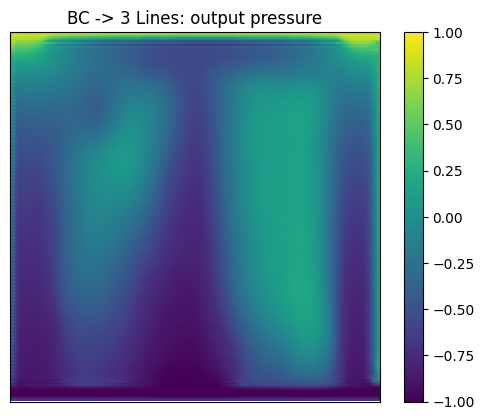

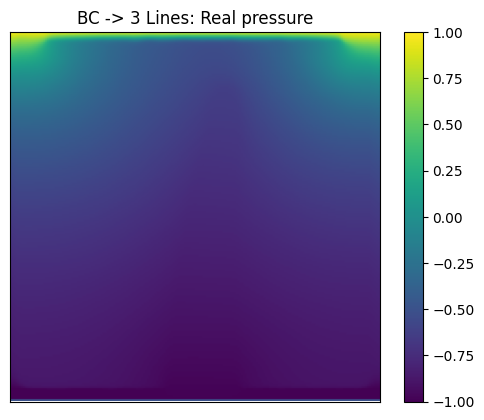

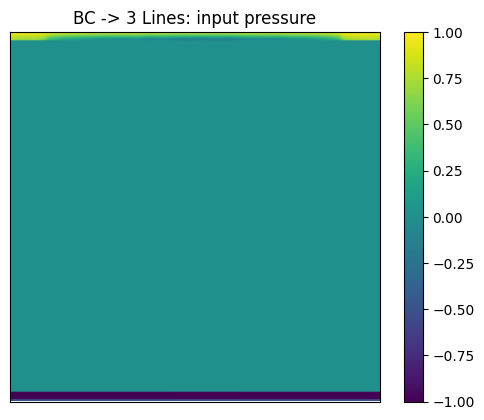

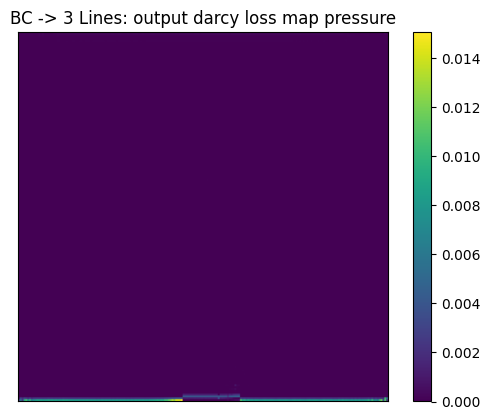

In [ ]:
feat,label = test_data[300]
feat = feat.cuda().unsqueeze(0)
label = label.cuda().unsqueeze(0)
p_loss, out = darcy_loss(model, feat)

channel =  1

model_title = "BC+sides -> 3 Lines"

plt.imshow(out.detach().cpu().numpy()[0,channel], vmin=-1,vmax=1)
plt.title(f"{model_title}: output {"pressure" if channel == 1 else "conductivity"}")
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.show()

plt.imshow(label.detach().cpu().numpy()[0,channel], vmin=-1,vmax=1)
plt.title(f"{model_title}: Real {"pressure" if channel == 1 else "conductivity"}")
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.show()

plt.imshow(feat.detach().cpu().numpy()[0,channel], vmin=-1,vmax=1)
plt.title(f"{model_title}: input {"pressure" if channel == 1 else "conductivity"}")
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.show()
'''
plt.imshow(mask.detach().cpu().numpy()[0], vmin=-1,vmax=1)
plt.title(f"{model_title}: training mask {"pressure" if channel == 1 else "conductivity"}")
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.show()
'''
plt.imshow(just_darcy(out).detach().cpu().numpy()[0,0])
plt.title(f"{model_title}: output darcy loss map {"pressure" if channel == 1 else "conductivity"}")
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
model = torch.load("minimum_info/Model0_2x2lines_unet.pt", weights_only=False).cuda()

In [ ]:
test_loss = 0
test_darcy = 0
with torch.no_grad(), torch.inference_mode(True):
    for feat,label in tqdm(test_loader):

        feat = feat.to(device)
        label = label.to(device)
        p_loss, out = darcy_loss(model, feat)
        test_darcy += p_loss.item()
        loss = crit(out, label) + p_loss
        test_loss += loss.item()

test_loss /= test_loader.__len__()
test_darcy /= test_loader.__len__()

In [ ]:
test_loss

In [ ]:
1.046144041752411